In [1]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)

True

## 1. Load Dataset

In [2]:
df = pd.read_csv('IMDB Dataset.csv')
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. Exploratory Data Analysis

In [3]:
print('Class distribution:')
print(df['sentiment'].value_counts())
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Review length stats (chars):')
print(df['review'].str.len().describe())

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64

Review length stats (chars):
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review, dtype: float64


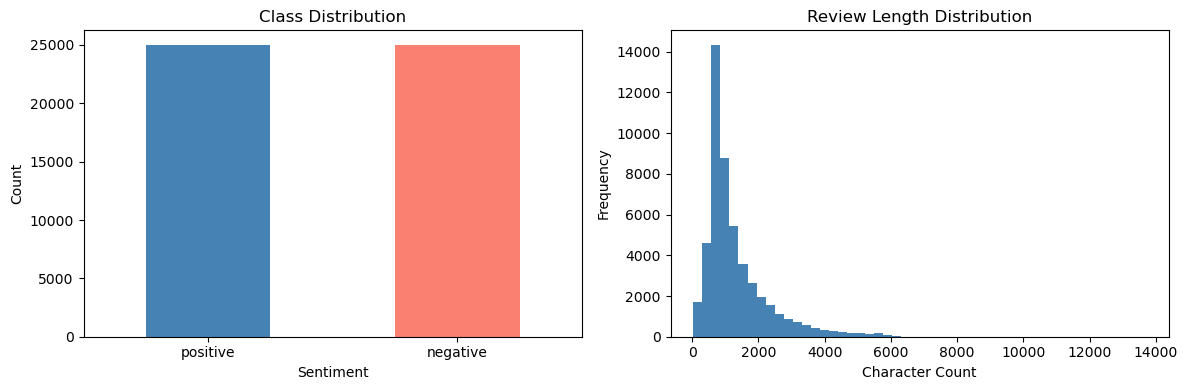

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

df['review'].str.len().plot(kind='hist', bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Character Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

## 3. Preprocessing

In [5]:
# Slang normalization: contractions expansion (relevant for informal English reviews)
CONTRACTIONS = {
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "don't": "do not", "doesn't": "does not",
    "didn't": "did not", "won't": "will not", "wouldn't": "would not",
    "can't": "cannot", "couldn't": "could not", "shouldn't": "should not",
    "mustn't": "must not", "needn't": "need not", "daren't": "dare not",
    "it's": "it is", "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "you've": "you have",
    "you'll": "you will", "you'd": "you would", "he's": "he is",
    "he'd": "he would", "she's": "she is", "she'd": "she would",
    "they're": "they are", "they've": "they have", "they'd": "they would",
    "we're": "we are", "we've": "we have", "we'd": "we would",
    "that's": "that is", "there's": "there is", "what's": "what is",
    "let's": "let us", "who's": "who is", "how's": "how is"
}

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    # Remove HTML tags (IMDB reviews contain HTML)
    text = re.sub(r'<.*?>', ' ', text)
    # Lowercase (case folding)
    text = text.lower()
    # Expand contractions (slang normalization)
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Stopword removal + stemming
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

In [6]:
# Verify preprocessing on a sample
sample = df['review'].iloc[0]
print('Original (first 300 chars):')
print(sample[:300])
print()
print('Cleaned:')
print(preprocess(sample)[:300])

Original (first 300 chars):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

Cleaned:
one review mention watch episod hook right exactli happen first thing struck brutal unflinch scene violenc set right word trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call nicknam given oswald maximum secur state penitentari focus mainli emerald citi 


In [7]:
# Apply to full dataset 
df['cleaned'] = df['review'].apply(preprocess)
df[['review', 'cleaned', 'sentiment']].head(3)

,review,cleaned,sentiment
0,One of the other reviewers has mentioned that ...,one review mention watch episod hook right exa...,positive
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...,positive
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...,positive


## 4. Feature Extraction (TF-IDF) & Train/Test Split

In [8]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['cleaned']
y = df['label']

# 80/20 split, stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 40000 | Test: 10000


In [9]:
# Unigram + bigram, limit vocab to top 50k features
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Feature matrix shape: {X_train_tfidf.shape}')

Feature matrix shape: (40000, 50000)


## 5. Modeling

In [10]:
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

print('=== Naive Bayes (Baseline) ===')
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

=== Naive Bayes (Baseline) ===
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      5000
    Positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [11]:
#SVM 
base_svm = LinearSVC(max_iter=2000, random_state=42)

svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt Scaling
    cv=5
)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print('=== SVM / LinearSVC (Main) ===')
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))

=== SVM / LinearSVC (Main) ===
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 6. Evaluation & Comparison

In [12]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM'],
    'Accuracy':  [accuracy_score(y_test, y_pred_nb),  accuracy_score(y_test, y_pred_svm)],
    'Precision': [precision_score(y_test, y_pred_nb), precision_score(y_test, y_pred_svm)],
    'Recall':    [recall_score(y_test, y_pred_nb),    recall_score(y_test, y_pred_svm)],
    'F1-Score':  [f1_score(y_test, y_pred_nb),        f1_score(y_test, y_pred_svm)]
}).set_index('Model').round(4)

results

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Naive Bayes,0.8791,0.8726,0.8878,0.8801
SVM,0.8989,0.8935,0.9058,0.8996


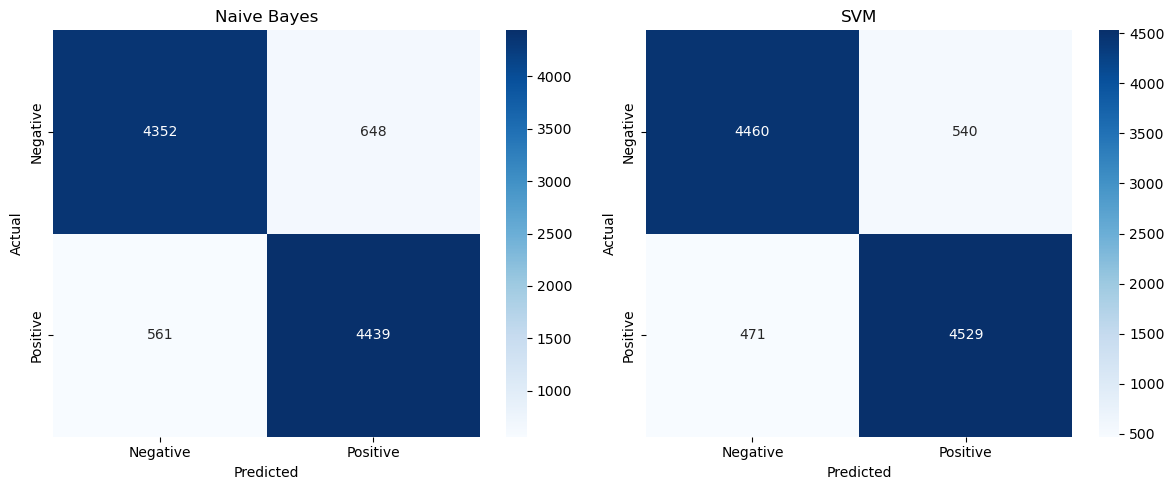

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Negative', 'Positive']

for ax, y_pred, title in zip(axes, [y_pred_nb, y_pred_svm], ['Naive Bayes', 'SVM']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

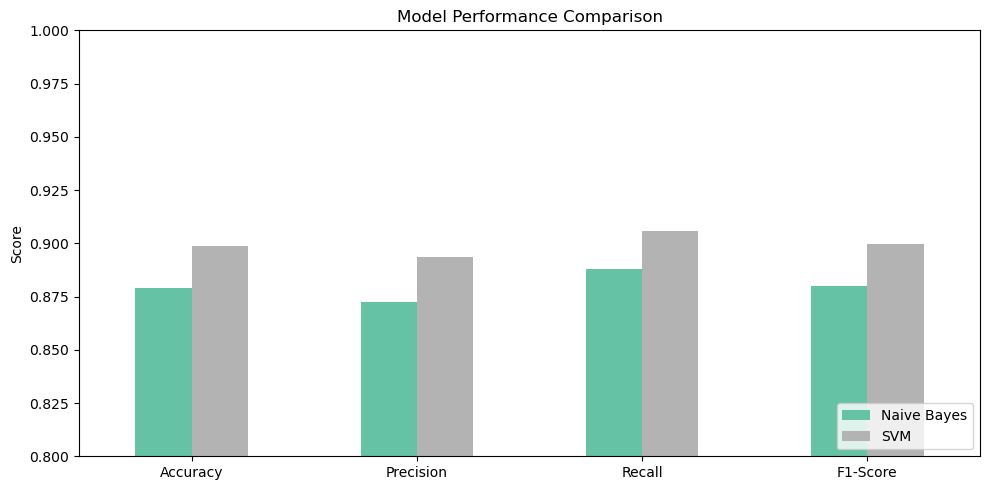

In [14]:
# Bar chart comparison
results.T.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 7. Save Models

In [15]:
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(nb,    'model_nb.pkl')
joblib.dump(svm,   'model_svm.pkl')
print('Saved: tfidf_vectorizer.pkl, model_nb.pkl, model_svm.pkl')

Saved: tfidf_vectorizer.pkl, model_nb.pkl, model_svm.pkl


## 8. Quick Inference Test

In [28]:
test_reviews = [
    "This movie was absolutely brilliant. The acting and story were outstanding.",
    "Terrible film. Waste of time, boring plot, and awful acting.",
    "It wasn't great but it wasn't bad either. Just mediocre overall.",
    "I honestly wasted my time. The movie was so boring and the characters were completely terrible."
]

for review in test_reviews:
    cleaned = preprocess(review)
    vec = tfidf.transform([cleaned])
    pred_nb  = 'Positive' if nb.predict(vec)[0] == 1 else 'Negative'
    pred_svm = 'Positive' if svm.predict(vec)[0] == 1 else 'Negative'
    print(f'Review : {review[:60]}...')
    print(f'NB     : {pred_nb}  |  SVM: {pred_svm}')
    print()

Review : This movie was absolutely brilliant. The acting and story we...
NB     : Positive  |  SVM: Positive

Review : Terrible film. Waste of time, boring plot, and awful acting....
NB     : Negative  |  SVM: Negative

Review : It wasn't great but it wasn't bad either. Just mediocre over...
NB     : Negative  |  SVM: Negative

Review : I honestly wasted my time. The movie was so boring and the c...
NB     : Negative  |  SVM: Negative

